In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
from src.data_loader import load_data

df = load_data()

In [7]:
import src.data_loader as dl

print(dl.__file__)
print(dir(dl))

/Users/adityasaurav/Desktop/Retail_Demand_Forecasting/src/data_loader.py
['URL', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'connection_url', 'create_engine', 'engine', 'load_data', 'pd']


In [8]:
daily = (
    df.groupby("Date")["Demand"]
      .sum()
      .reset_index()
)

daily["Date"] = pd.to_datetime(daily["Date"])
daily = daily.sort_values("Date")

daily.head()

,Date,Demand
0,2022-01-01,10060
1,2022-01-02,10814
2,2022-01-03,11317
3,2022-01-04,11469
4,2022-01-05,11724


In [9]:
daily["Lag_1"] = daily["Demand"].shift(1)
daily["Lag_7"] = daily["Demand"].shift(7)
daily["Lag_30"] = daily["Demand"].shift(30)

In [10]:
daily["Rolling_Mean_7"] = daily["Demand"].rolling(7).mean()
daily["Rolling_Std_7"] = daily["Demand"].rolling(7).std()

In [11]:
daily["Month"] = daily["Date"].dt.month
daily["DayOfWeek"] = daily["Date"].dt.dayofweek
daily["Quarter"] = daily["Date"].dt.quarter

In [12]:
daily = daily.dropna()

daily.head()

,Date,Demand,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Std_7,Month,DayOfWeek,Quarter
30,2022-01-31,10028,9553.0,10570.0,10060.0,10318.285714,532.993657,1,0,1
31,2022-02-01,10791,10028.0,9818.0,10814.0,10457.285714,507.020616,2,1,1
32,2022-02-02,12698,10791.0,10584.0,11317.0,10759.285714,992.365476,2,2,1
33,2022-02-03,12779,12698.0,10659.0,11469.0,11062.142857,1247.388396,2,3,1
34,2022-02-04,11363,12779.0,10522.0,11724.0,11182.285714,1227.028078,2,4,1


In [13]:
X = daily.drop(["Date", "Demand"], axis=1)
y = daily["Demand"]

In [14]:
split = int(len(daily) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [15]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
pred = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1020.9890747070312
RMSE: 1431.9350980404106
R²: 0.33378684520721436


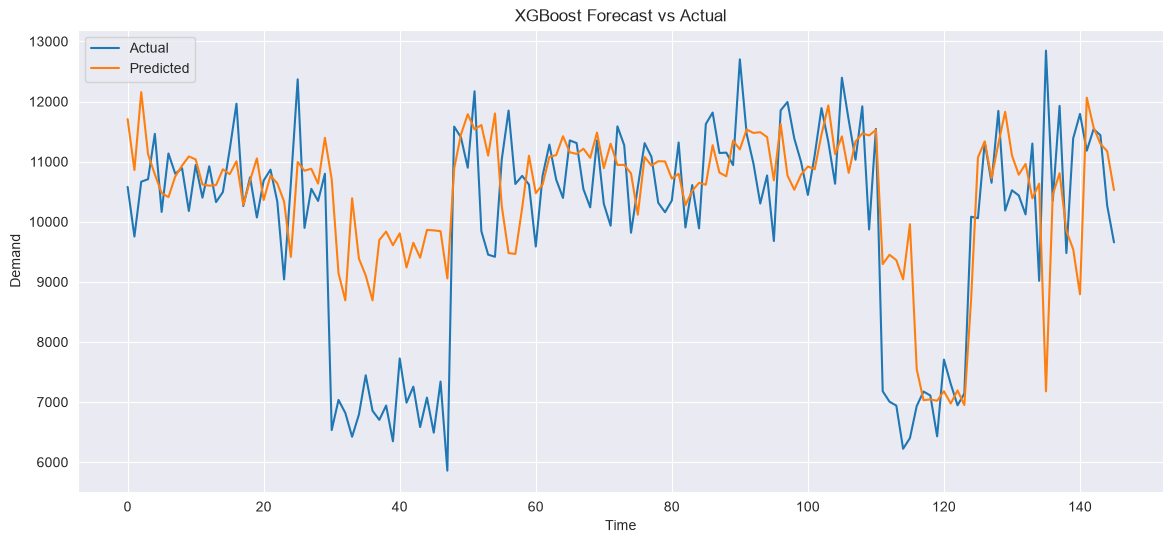

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.show()

In [19]:
forecast_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred
})

forecast_results.to_csv(
    "../data/forecast_results.csv",
    index=False
)

print("Forecast results saved successfully!")

Forecast results saved successfully!
